In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carregar os dados
df = pd.read_csv('../data/phishing_email_detection_2026_dataset.csv')

# 2. Primeira olhada nos dados
print("--- Informações Gerais ---")
print(df.info())

print("\n--- Resumo Estatístico ---")
print(df.describe())

--- Informações Gerais ---
<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   email_id            1500 non-null   int64
 1   sender_email        1500 non-null   str  
 2   subject             1500 non-null   str  
 3   has_link            1500 non-null   int64
 4   has_attachment      1500 non-null   int64
 5   urgency_score       1500 non-null   int64
 6   spelling_errors     1500 non-null   int64
 7   email_length_words  1500 non-null   int64
 8   is_phishing         1500 non-null   int64
dtypes: int64(7), str(2)
memory usage: 105.6 KB
None

--- Resumo Estatístico ---
          email_id     has_link  has_attachment  urgency_score  \
count  1500.000000  1500.000000     1500.000000    1500.000000   
mean    750.500000     0.629333        0.512667       5.722667   
std     433.157015     0.483144        0.500006       3.002182   
min       1.0000

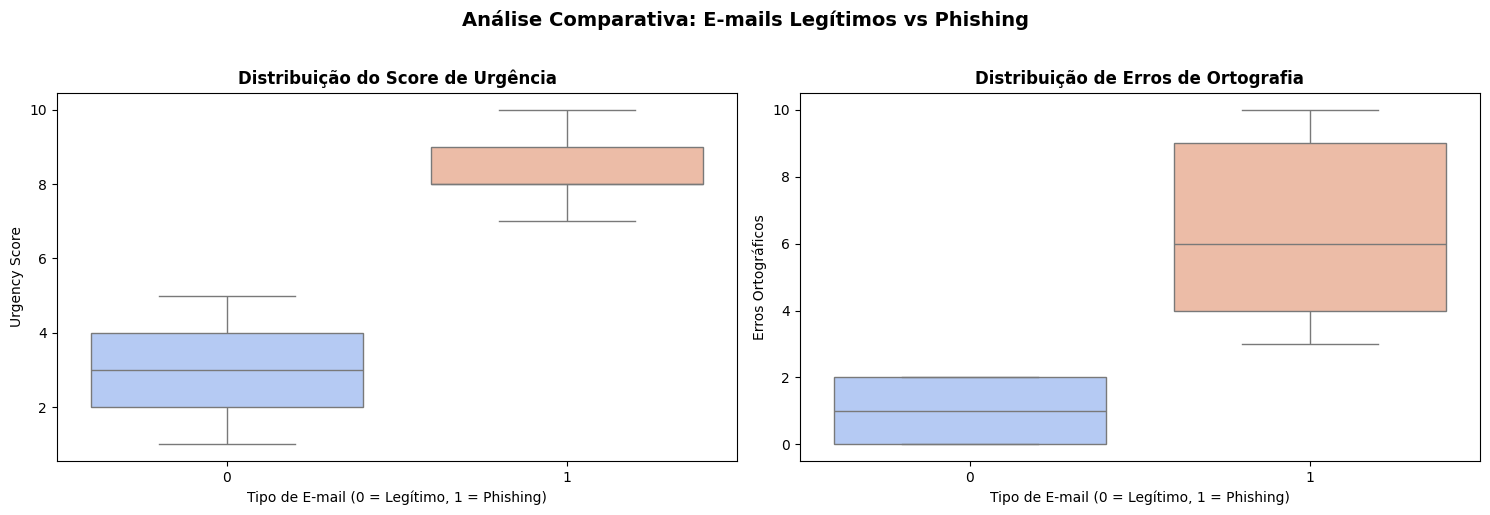

In [6]:
# 1. O fator Urgência e Erros Ortográficos
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot para Urgência (Ajustado)
sns.boxplot(
    ax=axes[0], 
    data=df, 
    x='is_phishing', 
    y='urgency_score', 
    hue='is_phishing', 
    palette='coolwarm', 
    legend=False
)
axes[0].set_title('Distribuição do Score de Urgência', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tipo de E-mail (0 = Legítimo, 1 = Phishing)')
axes[0].set_ylabel('Urgency Score')

# Boxplot para Erros Ortográficos (Ajustado)
sns.boxplot(
    ax=axes[1], 
    data=df, 
    x='is_phishing', 
    y='spelling_errors', 
    hue='is_phishing', 
    palette='coolwarm', 
    legend=False
)
axes[1].set_title('Distribuição de Erros de Ortografia', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tipo de E-mail (0 = Legítimo, 1 = Phishing)')
axes[1].set_ylabel('Erros Ortográficos')

plt.suptitle('Análise Comparativa: E-mails Legítimos vs Phishing', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [4]:
# 2. Links e Anexos são determinantes?
# Proporção de links em e-mails normais vs phishing
link_phishing = pd.crosstab(df['has_link'], df['is_phishing'], normalize='columns') * 100
print("--- Porcentagem de Links por Tipo de E-mail ---")
print(link_phishing)

--- Porcentagem de Links por Tipo de E-mail ---
is_phishing          0          1
has_link                         
0            48.026316  25.810811
1            51.973684  74.189189


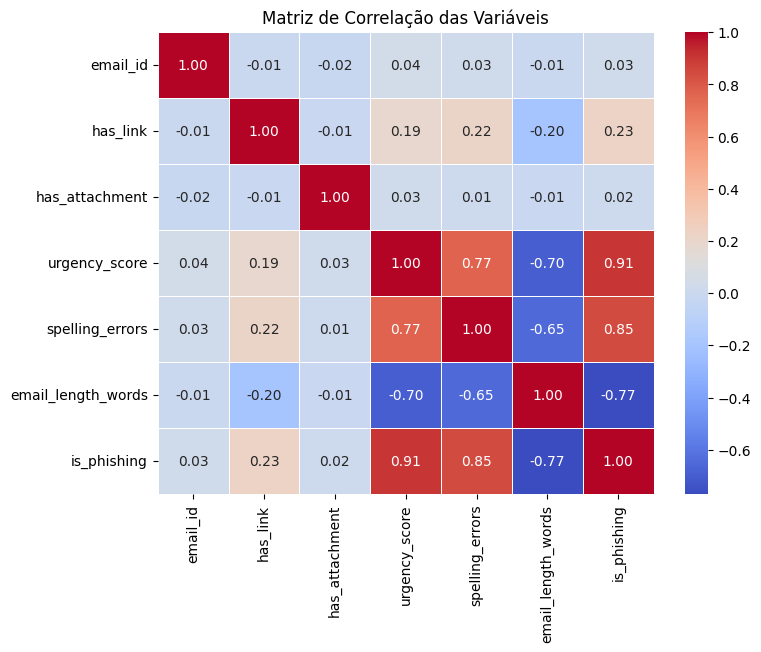

In [5]:
#3. Matriz de Correlação
plt.figure(figsize=(8, 6))
# Selecionando apenas colunas numéricas para a correlação
corr_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlação das Variáveis')
plt.show()